# Metric Catalog & Ownership

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/metric-catalog/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/metric-catalog/demo.ipynb)

> Which metrics exist, and who owns them? A catalog registers every metric with an owner, a tier, and governance checks that flag the ones nobody is minding.

The **finale of Month 11.** Day 101 defined metrics; this is where they *live* - a registry with
ownership, tiers, dependencies, and automated governance. It answers the two questions every data
leader eventually asks: "how many metrics do we even have?" and "who do I call when this one breaks?"

**What this notebook covers**
1. Registering metrics with ownership + tier + dependencies
2. Searching and filtering the catalog
3. Automated governance: unowned, stale, broken-dependency checks
4. A catalog health score
5. Ownership + governance, visualized


## Step 1 - A registry, not a spreadsheet

Each metric carries the metadata that makes it governable: a definition, an **owner**, a tier
(1 = board-critical), dependencies on other metrics, and when it was last reviewed.

In [1]:
from catalog import sample_catalog

cat = sample_catalog()
for m in cat.search():
    print(f"  T{m.tier}  {m.name:<16} owner={m.owner or '(none)':<14} {m.status}")


  T1  active_users     owner=growth-lead    active
  T1  revenue          owner=finance-lead   active
  T2  activation_rate  owner=growth-lead    active
  T2  arpu             owner=(none)         active
  T2  nps              owner=cx-lead        active
  T3  legacy_signups   owner=(none)         deprecated


## Step 2 - Find anything

"Which metrics does Growth own?" "What's tier 1?" A catalog is only useful if it's searchable by
the questions people actually ask.

In [2]:
print("Tier-1 (board-critical):", [m.name for m in cat.search(tier=1)])
print("Owned by Growth:        ", [m.name for m in cat.search(team="Growth")])
print("Deprecated:             ", [m.name for m in cat.search(status="deprecated")])


Tier-1 (board-critical): ['active_users', 'revenue']
Owned by Growth:         ['active_users', 'activation_rate', 'legacy_signups']
Deprecated:              ['legacy_signups']


## Step 3 - Governance runs itself

The value isn't the list - it's catching the rot: an active metric with **no owner**, one not
reviewed in months, or one that **depends on a deprecated metric** (a silent time bomb). Severity
scales with tier.

In [3]:
for i in sorted(cat.governance_issues(), key=lambda x: {"high":0,"medium":1,"low":2}[x.severity]):
    print(f"[{i.severity.upper():<6}] {i.metric:<16} {i.kind:<15} {i.message}")


[HIGH  ] activation_rate  deprecated_dep  Depends on deprecated metric 'legacy_signups'
[MEDIUM] arpu             no_owner        Tier-2 metric has no owner
[MEDIUM] arpu             stale           Not reviewed in 200 days
[LOW   ] nps              never_reviewed  Never reviewed


## Step 4 - Catalog health at a glance

One row a data leader can put in a board deck: how many metrics, what % are owned, how many
governance issues are open.

In [4]:
h = cat.health()
print(f"Metrics:          {h['total']} ({h['active']} active, {h['deprecated']} deprecated)")
print(f"Ownership:        {h['owned_pct']}% of active metrics have an owner")
print(f"Governance issues:{h['issues']} ({h['high_issues']} high severity)")
print(f"By tier:          {h['by_tier']}")


Metrics:          6 (5 active, 1 deprecated)
Ownership:        80% of active metrics have an owner
Governance issues:4 (1 high severity)
By tier:          {1: 2, 2: 3, 3: 1}


## Step 5 - Ownership + issues, visualized

Two things a steward tracks: the ownership gap (unowned active metrics) and the open issues by
severity. Both should trend to zero.

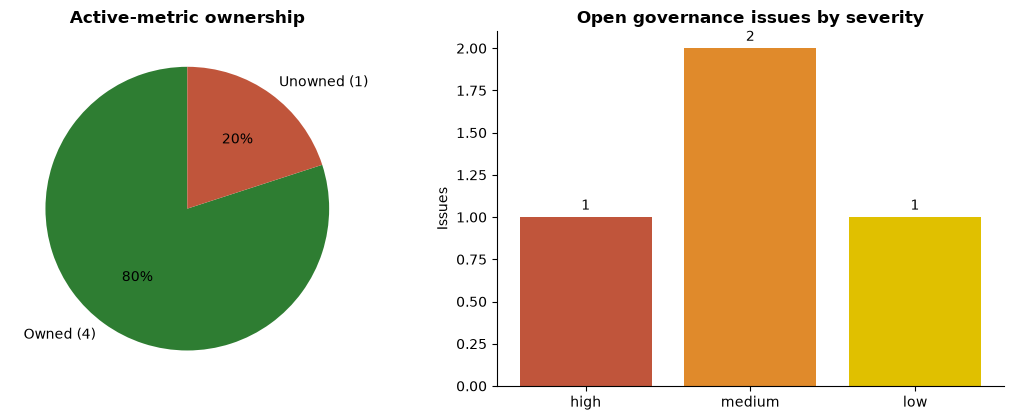

In [5]:
import matplotlib.pyplot as plt

active = [m for m in cat.metrics.values() if m.status == "active"]
owned = sum(1 for m in active if m.owner)
unowned = len(active) - owned

issues = cat.governance_issues()
sev_counts = {s: sum(1 for i in issues if i.severity == s) for s in ["high", "medium", "low"]}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

ax1.pie([owned, unowned], labels=[f"Owned ({owned})", f"Unowned ({unowned})"],
        colors=["#2e7d32", "#c0553b"], autopct="%1.0f%%", startangle=90)
ax1.set_title("Active-metric ownership", fontsize=12, weight="bold")

colors = {"high": "#c0553b", "medium": "#e08a2b", "low": "#e0c000"}
bars = ax2.bar(list(sev_counts), list(sev_counts.values()),
               color=[colors[s] for s in sev_counts])
ax2.set_title("Open governance issues by severity", fontsize=12, weight="bold")
ax2.set_ylabel("Issues")
ax2.bar_label(bars, padding=3)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("catalog_health.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary — and Month 11 comes full circle

| Governance check | Example caught |
|------------------|----------------|
| no owner | `arpu` (tier-2, unowned) |
| stale review | `arpu` (200 days) |
| never reviewed | `nps` |
| depends on deprecated | `activation_rate` → `legacy_signups` |

Day 101 gave metrics a single **definition**; Day 110 gives them a single **home** - with an owner,
a tier, and checks that surface neglect before it becomes an incident. Together they're the backbone
of a trustworthy BI layer: define once, own explicitly, govern automatically.

**Extend it:** sync entries from your metrics-layer YAML (Day 101), block deploys on high-severity
issues in CI, and auto-open a ticket to the owner when a metric goes stale.

In [6]:
# --- Register your own metric ---
# from catalog import MetricEntry
# cat.register(MetricEntry("gross_margin", "Gross profit / revenue", owner="finance-lead",
#                          team="Finance", tier=1, depends_on=["revenue"], last_reviewed="2026-07-01"))
# print(cat.health())


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 110,
**closing out Month 11: Analytics Engineering & BI**.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`